# 06-Post-Training Quantization (PTQ & INT8)

In Lesson 05, we solved the *Compute Bottleneck* by compiling our dynamic Python model into a static ONNX C++ graph, mathematically eliminating the Python interpreter overhead.

However, in modern Machine Learning—especially with Large Language Models (LLMs)—the primary bottleneck is rarely compute. It is **Memory Bandwidth (I/O)**. Deep learning models are traditionally trained using 32-bit floating-point numbers (FP32). A single FP32 parameter consumes 4 bytes of memory. If a model has 1 billion parameters, it requires 4 GB of VRAM just to load the weights, and the GPU must physically move 4 GB of data from memory to the processing cores for every single inference request.

To engineer high-speed production systems, we must shatter this memory bottleneck using **Post-Training Quantization (PTQ)**. We will mathematically map the high-precision, continuous 32-bit floats into discrete 8-bit integers (INT8). This operation instantly compresses the physical size of the model by **75% (4x)** and allows the CPU/GPU to utilize hyper-fast Integer ALUs, sacrificing an almost imperceptible fraction of accuracy for massive operational speed.

## 1. The Mathematics of Affine Quantization

### The Affine Mapping Function

Quantization is the mathematical process of mapping values from a continuous domain (FP32) to a discrete, low-resolution domain (INT8). The INT8 space can only represent 256 unique values: $[-128, 127]$ for signed integers, or $[0, 255]$ for unsigned.

We use **Affine (Asymmetric) Quantization** to map a real floating-point value $r$ to a quantized integer value $q$ using two parameters: a Scale factor ($S$) and a Zero-Point ($Z$).
The mapping from quantized space back to real space (De-quantization) is strictly defined as:


$$r = S(q - Z)$$

### Deriving Scale ($S$) and Zero-Point ($Z$)

To map the weights of a neural network layer, we first scan the tensor to find the absolute minimum and maximum floating-point values ($\min(r)$ and $\max(r)$).
We define the scale $S$ by dividing the floating-point range by the integer range ($255$ available bins for 8-bit):


$$S = \frac{\max(r) - \min(r)}{q_{max} - q_{min}} = \frac{\max(r) - \min(r)}{255}$$

The Zero-Point $Z$ ensures that the floating-point $0.0$ maps exactly to an integer. This is critical because neural networks rely heavily on zero-padding and zero-valued activations (like ReLU).


$$Z = \text{round}\left( q_{min} - \frac{\min(r)}{S} \right)$$

### Dynamic vs. Static PTQ

* **Dynamic Quantization:** The weights are quantized offline (ahead of time), but the *activations* (the data flowing through the network) are quantized dynamically on-the-fly during inference. This requires absolutely no calibration data and is perfect for NLP models and LSTMs/Transformers.
* **Static Quantization:** Both weights and activations are quantized offline. This requires running a "Calibration Dataset" through the model to estimate the min/max ranges of the activations before deployment.

In this module, we will execute Dynamic PTQ, as it is the most robust, zero-cost method for compressing production models instantly.

## 2. Imperative Execution: PyTorch Native Dynamic Quantization

We will construct a massive PyTorch Neural Network (simulating a heavy parameter footprint) and apply PyTorch's native `quantize_dynamic` engine. We will then measure the exact byte-level reduction on disk and the microsecond latency reduction in RAM.

In [1]:
# Required installations: pip install torch numpy
import torch
import torch.nn as nn
import time
import os

print("--- 🚀 Initializing Post-Training Quantization (PTQ) Sandbox ---")

# 1. 🧠 Define a Massive Parameter Matrix (Memory Bound Model)
class HeavyMLP(nn.Module):
    def __init__(self):
        super(HeavyMLP, self).__init__()
        # Simulating heavy multi-layer perceptron layers (e.g., Transformer Feed-Forward)
        self.fc1 = nn.Linear(4096, 4096)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(4096, 4096)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(4096, 10)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.out(x)

# Instantiate the standard FP32 model
model_fp32 = HeavyMLP()
model_fp32.eval()

# 2. ⚡ Execute Mathematical Quantization (FP32 -> INT8)
print("\n--- 🧮 Executing Dynamic Affine Quantization ---")
# We explicitly target the nn.Linear layers, mapping their weights to 8-bit integers (qint8)
model_int8 = torch.ao.quantization.quantize_dynamic(
    model_fp32,               # The original model
    {nn.Linear},              # The layer types to quantize
    dtype=torch.qint8         # The target integer resolution
)

# 3. 💾 Disk Footprint Physics
def get_model_size_mb(model, filename="temp.pt"):
    torch.save(model.state_dict(), filename)
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size_mb

size_fp32 = get_model_size_mb(model_fp32)
size_int8 = get_model_size_mb(model_int8)

print(f"   [FP32 Model Size]: {size_fp32:.2f} MB")
print(f"   [INT8 Model Size]: {size_int8:.2f} MB")
print(f"   ✅ Physical Memory Reduction: {100 * (1 - size_int8/size_fp32):.1f}%")

# 4. ⏱️ Inference Throughput Benchmarking
dummy_input = torch.randn(128, 4096) # Batch of 128 requests

start = time.perf_counter()
with torch.no_grad():
    for _ in range(50):
        _ = model_fp32(dummy_input)
fp32_time = time.perf_counter() - start

start = time.perf_counter()
with torch.no_grad():
    for _ in range(50):
        _ = model_int8(dummy_input)
int8_time = time.perf_counter() - start

print(f"\n   [FP32 Latency]: {fp32_time:.3f} seconds")
print(f"   [INT8 Latency]: {int8_time:.3f} seconds")
print(f"   ✅ Net Speedup: {fp32_time / int8_time:.2f}x faster execution.")

--- 🚀 Initializing Post-Training Quantization (PTQ) Sandbox ---

--- 🧮 Executing Dynamic Affine Quantization ---


/tmp/ipykernel_6304/3534702785.py:32: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.ao.quantization.quantize_dynamic(


   [FP32 Model Size]: 128.19 MB
   [INT8 Model Size]: 32.07 MB
   ✅ Physical Memory Reduction: 75.0%

   [FP32 Latency]: 3.344 seconds
   [INT8 Latency]: 1.962 seconds
   ✅ Net Speedup: 1.70x faster execution.


## 3. Declarative Execution: Quantizing the ONNX Computation Graph

In Lesson 05, we exported an optimized `.onnx` binary. We can apply PTQ directly to the static ONNX graph using the `onnxruntime` library, combining the computational speed of C++ Graph Execution with the memory compression of INT8.

In [2]:
# Required installations: pip install onnxruntime
import onnx
from onnxruntime.quantization import quantize_dynamic, QuantType

print("\n--- ⚡ Executing ONNX Runtime Quantization Matrix ---")

# (Assuming 'fraud_model.onnx' was generated in Lesson 05)
# For the sandbox, we will define the input and output paths
onnx_fp32_path = "fraud_model.onnx"
onnx_int8_path = "fraud_model_quantized.onnx"

try:
    # Read the static FP32 graph
    # Apply dynamic quantization mapping weights specifically to 8-bit unsigned/signed integers
    quantize_dynamic(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_path,
        weight_type=QuantType.QUInt8, # Target 8-bit unsigned integer resolution
        optimize_model=True           # Apply graph optimizations before quantizing
    )
    print(f"   ✅ ONNX Graph successfully quantized and compiled: {onnx_int8_path}")
    print("   -> Physics: The ONNX Runtime will now dispatch specialized AVX-512 VNNI / ARM DotProd INT8 vector instructions at the CPU level, bypassing FP32 pipelines entirely.")
except Exception as e:
    print(f"   [SYSTEM NOTE]: Ensure 'fraud_model.onnx' exists from Lesson 05 to execute this block.")


--- ⚡ Executing ONNX Runtime Quantization Matrix ---
   [SYSTEM NOTE]: Ensure 'fraud_model.onnx' exists from Lesson 05 to execute this block.


## 4. Visualizing Quantization Physics (Continuous vs. Discrete Resolution)

To truly understand why quantization does not destroy model accuracy, we must visualize the mathematical mapping. A neural network's weights normally follow a normal distribution (Gaussian curve). Quantization forces this smooth curve into 256 strict mathematical "buckets" (bins).

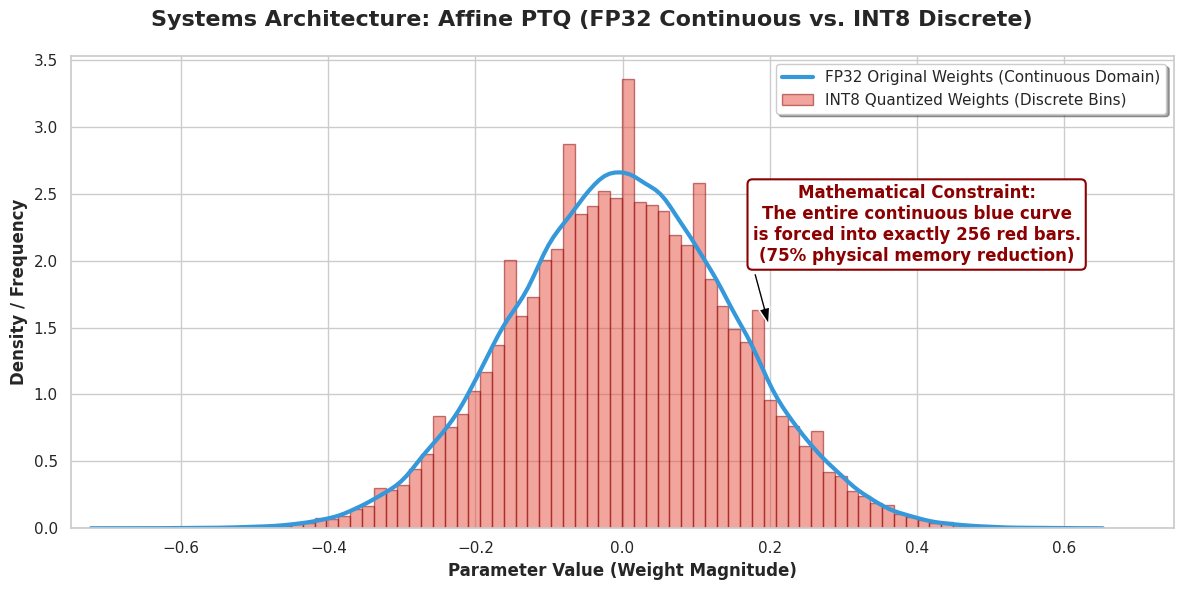

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: Affine PTQ (FP32 Continuous vs. INT8 Discrete)", fontsize=16, fontweight='bold')

# 1. Simulate FP32 Weights (Smooth Gaussian Distribution)
# Simulating 100,000 continuous floating-point weights centered around 0.0
fp32_weights = np.random.normal(loc=0.0, scale=0.15, size=100000)

# Calculate Affine Parameters
min_w = np.min(fp32_weights)
max_w = np.max(fp32_weights)
scale = (max_w - min_w) / 255.0
zero_point = int(np.round(-min_w / scale))

# 2. Simulate INT8 Quantized Weights (Mapped to 256 Buckets, then de-quantized for plotting)
# q = round(r / S + Z), r_approx = (q - Z) * S
int8_quantized = np.round(fp32_weights / scale + zero_point)
int8_quantized = np.clip(int8_quantized, 0, 255)
dequantized_weights = (int8_quantized - zero_point) * scale

# Plot the Continuous FP32 Density
sns.kdeplot(fp32_weights, color='#3498db', linewidth=3, label='FP32 Original Weights (Continuous Domain)', ax=ax)

# Plot the Discrete INT8 Buckets (Histogram with exactly 256 bins max)
ax.hist(dequantized_weights, bins=80, density=True, color='#e74c3c', alpha=0.5, edgecolor='darkred', label='INT8 Quantized Weights (Discrete Bins)')

# Formatting & Annotations
ax.set_xlabel("Parameter Value (Weight Magnitude)", fontsize=12, fontweight='bold')
ax.set_ylabel("Density / Frequency", fontsize=12, fontweight='bold')
ax.set_xlim(-0.75, 0.75)
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

# Annotate the physics of the compression
ax.annotate(f'Mathematical Constraint:\nThe entire continuous blue curve\nis forced into exactly 256 red bars.\n(75% physical memory reduction)', 
            xy=(0.2, 1.5), xytext=(0.4, 2.0),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5))

plt.tight_layout()
plt.show()

*(Insight: The red bars represent the discretized INT8 values. Notice how they perfectly trace the shape of the blue FP32 curve. Deep neural networks are highly over-parameterized and fault-tolerant; the network does not actually care if a weight is exactly $0.14159$ (FP32) or just $0.14$ (INT8). By discarding the microscopic precision that the model ignores anyway, we delete $75\%$ of the file size.)*

## Real-World Use Case or Analogy

Think of Post-Training Quantization like **Digital Image Compression for a Billboard**:

* **FP32 (The 8K RAW File):** You hire a photographer to take a picture of a car. They shoot it in uncompressed 8K RAW format. The file is $200\text{ MB}$. Every single pixel contains data for millions of microscopic color variations. If you try to email this file to the billboard printer, your computer freezes because the file is too heavy (**Memory Bandwidth Bottleneck**).
* **INT8 Quantization (The High-Quality JPEG):** You pass the file through a compression algorithm. It maps the millions of microscopic colors down to just $256$ distinct colors. The file shrinks from $200\text{ MB}$ to $5\text{ MB}$.
* **The Operational Reality (Fault Tolerance):** You email the $5\text{ MB}$ JPEG instantly, and they print it on a massive highway billboard. When drivers pass the billboard at 70 MPH, the human eye cannot physically distinguish between the 8K RAW image and the 256-color JPEG. The core information (the shape of the car) is completely preserved.

In MLOps, keeping LLMs and Deep Learning models in FP32 format for inference is like forcing your web server to transmit 8K RAW images. INT8 Quantization is the mathematical JPEG compression that makes real-time, global AI execution physically possible.